Lucas Galindo - 202222210
Tomas Diaz - 202220658

Primero vamos a cargar los datos y tener una vista inicial de como estan organizados y medidas estadisticas generales para entender y buscar posibless anomalias

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from importlib.metadata import version

from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols
from sklearn.preprocessing import PolynomialFeatures

from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
from sklearn.inspection import permutation_importance

df = pd.read_csv("Datos Lab 1.csv")
datos = df.copy()
df = pd.read_csv("Datos Test Lab 1.csv", sep=";")




In [2]:

datos = datos[datos["Total Cholesterol (mg/dL)"] > 0]
datos = datos[datos["Estimated LDL (mg/dL)"] > 0]
datos = datos[datos["CVD Risk Score"] >= 0]
datos = datos[datos["BMI"] >= 15]
datos = datos[datos["Age"] >= 18]
datos = datos[datos["Systolic BP"] >= 70]
datos = datos[datos["Systolic BP"] <= 200]
datos = datos[datos["Diastolic BP"] >= 40]
datos = datos[datos["Diastolic BP"] <= 130]
datos = datos[datos["HDL (mg/dL)"] >= 20]
datos = datos[datos["Fasting Blood Sugar (mg/dL)"] >= 50]
datos = datos[datos["Fasting Blood Sugar (mg/dL)"] <= 250]
    
print(len(datos))

1095


In [3]:
print(datos.duplicated().sum())
duplicados = datos.groupby(['Patient ID']).size()
duplicados = duplicados[duplicados > 1]


98


In [ ]:
datos = datos.drop_duplicates()
datos = datos.groupby(['Patient ID', 'Date of Service']).filter(lambda x: x['CVD Risk Score'].nunique() <= 1)
duplicados = datos.groupby(['Patient ID']).size()
duplicados = duplicados[duplicados > 1]

834


In [6]:

cols_drop = ['Patient ID', 'Date of Service', 'Height (cm)', 
             'Blood Pressure (mmHg)', 'Blood Pressure Category', 
             'Waist-to-Height Ratio', 'CVD Risk Level',
             'Weight (kg)', 'Height (m)', 'Estimated LDL (mg/dL)']

def drop_columns(datos):
    datos = datos.drop(columns=cols_drop, errors='ignore')
    return datos

drop_columns_tr = FunctionTransformer(drop_columns)

In [8]:
datos = datos[datos["CVD Risk Score"] < 30]
target = 'CVD Risk Score'
x = datos.drop(columns=[target])
y = datos[target]


En este caso utilizaremos el 80% de los datos para entrenar el modelo y el 20% de estos para evaluarlo. tomamos esta decision porque nos permite, tener suficiente informacion para el aprendisaje y tener una cantidad optima para evaluarlos

In [9]:
strat = datos['CVD Risk Level']
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=40, stratify=strat)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(667, 23) (167, 23) (667,) (167,)


Ahora se identifican las numericas y categoricas. Para evitar valores nulos, cuando se encuentra un numerico nulo se le coloca la media de esta categoria y si es un categorico, se coloca el mas comun. De igual manera, se estandarizan las variables. Para las categoricas utilizamos el oneHotEncoder, para que se puedan analizar en modo de binarios, usando el ignore para que se puedan manejar categorias no vistas en el entrenamiento y drop if binary para que se elimine las columnas generadas si la variables ya es binaria, para reducir redundancia

In [10]:
numeric_f = ['Age', 
             'Abdominal Circumference (cm)', 
             'Systolic BP', 
             'Diastolic BP', 
             'Total Cholesterol (mg/dL)', 
             'HDL (mg/dL)', 
             'Fasting Blood Sugar (mg/dL)', 
             'BMI']
categorical_f = ['Sex', 
                 'Smoking Status', 
                 'Diabetes Status',
                 'Physical Activity Level', 
                 'Family History of CVD']

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])



Ahora creamos el column transformer para que se apliquen las transformaciones segun el tipo de variable

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_f),
        ("cat", categorical_transformer, categorical_f),
    ]
)

Ahora creamos el pipeline_regresion, para que todos los datos tengan el mismo procedimiento.

In [35]:


pipeline_poly = Pipeline([
    ("dropper", drop_columns_tr),
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])


from sklearn import set_config
set_config(display="diagram")
pipeline_poly

Pipeline(steps=[('dropper',
                 FunctionTransformer(func=<function drop_columns at 0x126c1ddc0>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Abdominal Circumference '
                                                   '(cm)',
                                                   'Systolic BP',
                                                   'Diastolic BP',
                                                   'Total Cholesterol (mg/dL)',
                                                   'HDL (mg/dL)',
                                                   'Fasting Blood Sugar '
                                                   '(mg/dL)',
                                                   'BMI']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Smoking Status',
                                                   'Diabetes Status',
                                                   'Physical Activity Level',
                                                   'Family History of CVD'])])),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [36]:


param_grid = {
    "poly__degree": [1, 2, 3, 4, 5]
}

grid = GridSearchCV(
    pipeline_poly,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True
)

grid.fit(X_train, y_train)

mejor = grid.best_estimator_


In [ ]:
y_mejor = mejor.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_mejor))
mae_poly = mean_absolute_error(y_test, y_mejor)
r2_poly = r2_score(y_test, y_mejor)

print("POLYNOMIAL")
print("Grado:", grid.best_params_)
print("RMSE:", rmse_poly)
print("MAE:", mae_poly)
print("R2:", r2_poly)


POLYNOMIAL
Best degree: {'poly__degree': 2}
RMSE: 0.03186429166049346
MAE: 0.016749805498610593
R2: 0.9500888830882059


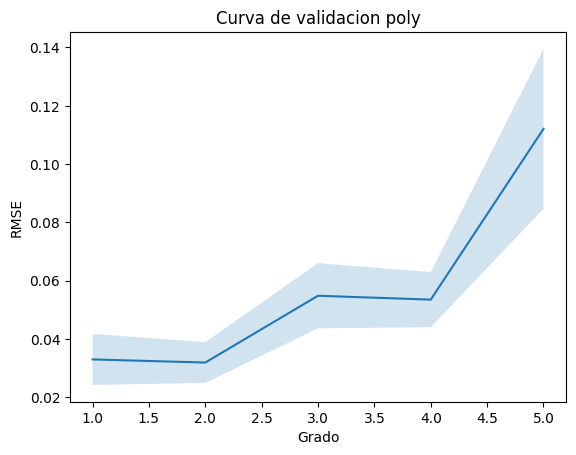

In [38]:
results_poly = pd.DataFrame(grid_poly.cv_results_)

degrees = results_poly["param_poly__degree"]
mean_scores = -results_poly["mean_test_score"]
std_scores = results_poly["std_test_score"]

plt.figure()
plt.plot(degrees, mean_scores)
plt.fill_between(degrees,
                 mean_scores - std_scores,
                 mean_scores + std_scores,
                 alpha=0.2)
plt.xlabel("Grado")
plt.ylabel("RMSE")
plt.title("Curva de validacion poly")
plt.show()


In [41]:
pipe_ridge = Pipeline([
    ("dropper", drop_columns_tr),
    ("preprocessor", preprocessor),
    ("model", Ridge())
])
alphas = np.logspace(-4, 4, 20)

param_grid_ridge = {
    "model__alpha": alphas
}

grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_ridge.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_
print("Mejor alpha Ridge:", grid_ridge.best_params_)


Mejor alpha Ridge: {'model__alpha': np.float64(0.0001)}


In [42]:
y_pred_ridge = best_ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)


In [44]:
pipe_lasso = Pipeline([
    ("dropper", drop_columns_tr),
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])
param_grid_lasso = {
    "model__alpha": alphas
}

grid_lasso = GridSearchCV(
    pipe_lasso,
    param_grid=param_grid_lasso,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_
print("Mejor alpha Lasso:", grid_lasso.best_params_)


Mejor alpha Lasso: {'model__alpha': np.float64(0.00026366508987303583)}


In [45]:
y_pred_lasso = best_lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)


In [47]:
coef_lasso = best_lasso.named_steps["model"].coef_
print("Coeficientes Lasso:", coef_lasso)

Coeficientes Lasso: [ 0.00112316  0.00199564  0.05820698  0.00057374  0.06168937  0.00079729
  0.00172389  0.08004783  0.         -0.          0.11520055 -0.00211756
 -0.          0.001728   -0.00279704]


In [48]:
pipe_poly_ridge = Pipeline([
    ("dropper", drop_columns_tr),
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Ridge())
])

param_grid_poly_ridge = {
    "poly__degree": [1, 2, 3, 4],
    "model__alpha": alphas
}

grid_poly_ridge = GridSearchCV(
    pipe_poly_ridge,
    param_grid=param_grid_poly_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_poly_ridge.fit(X_train, y_train)

best_poly_ridge = grid_poly_ridge.best_estimator_


In [49]:
results = pd.DataFrame({
    "Modelo": ["Polinomial", "Ridge", "Lasso", "Poly+Ridge"],
    "RMSE": [rmse_poly, rmse_ridge, rmse_lasso, 
             np.sqrt(mean_squared_error(y_test, best_poly_ridge.predict(X_test)))],
    "MAE": [mae_poly, mae_ridge, mae_lasso,
            mean_absolute_error(y_test, best_poly_ridge.predict(X_test))],
    "R2": [r2_poly, r2_ridge, r2_lasso,
           r2_score(y_test, best_poly_ridge.predict(X_test))]
})

results.sort_values("RMSE")


,Modelo,RMSE,MAE,R2
3,Poly+Ridge,0.031367,0.016547,0.951636
0,Polinomial,0.031864,0.016750,0.950089
2,Lasso,0.037486,0.014947,0.930923
1,Ridge,0.037617,0.014966,0.930441


In [50]:
from sklearn.utils import resample

best_model = best_poly_ridge  # Cambiar si otro fue mejor

rmse_boot = []

for i in range(500):
    X_res, y_res = resample(X_test, y_test)
    y_pred_res = best_model.predict(X_res)
    rmse_boot.append(np.sqrt(mean_squared_error(y_res, y_pred_res)))

ci_lower = np.percentile(rmse_boot, 2.5)
ci_upper = np.percentile(rmse_boot, 97.5)

print("IC 95% RMSE:", ci_lower, "-", ci_upper)


IC 95% RMSE: 0.017301268696899276 - 0.04910065985420009


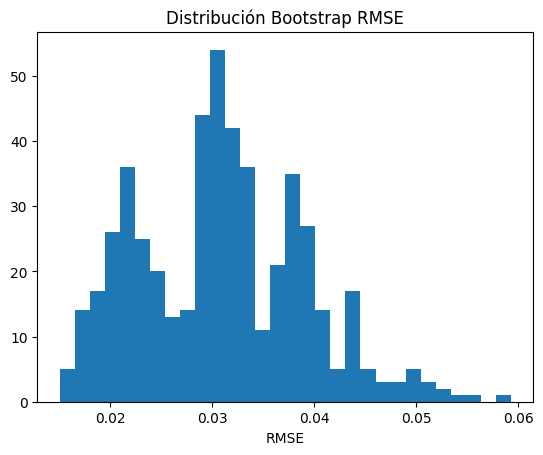

In [51]:
plt.figure()
plt.hist(rmse_boot, bins=30)
plt.xlabel("RMSE")
plt.title("Distribución Bootstrap RMSE")
plt.show()


In [52]:
print("CV RMSE Polynomial:", -grid_poly.best_score_)
print("CV RMSE Ridge:", -grid_ridge.best_score_)
print("CV RMSE Lasso:", -grid_lasso.best_score_)
print("CV RMSE Poly+Ridge:", -grid_poly_ridge.best_score_)


CV RMSE Polynomial: 0.03196206376510182
CV RMSE Ridge: 0.033040326628605024
CV RMSE Lasso: 0.032982300338429055
CV RMSE Poly+Ridge: 0.03183428049231761
